<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

Candidate Number: 154

Overall, the term paper is solved in an efficient and precise manner. All code runs and executes without errors, the printing of output is nicely formatted, vecotrization is correctly used to avoid unnecessary looping, and repeated calculations are mostly avoided by making reusable functions. 

Comments both in code and markdown cells are nicely presented, with good economical interpretations of the solutions. Code-comments are well formatted, especially in the sense that they clearly indicate what happens at which part of the code without unnecessary comments. The notebook very clearly separates parts and tasks, and printed output nicely orders steady-state values by category (workers, capitalists, ...). 

Some possible improvements could be made, mainly adding checks for root-finding convergence, reporting percentage-based quantities (interest rate, savings rate) as percentages, and consolidating repeated printing logic into the existing print-functions rather than adding extra cells. A shared `compute_period` helper could also reduce duplication between `compute_steady_state` and `simulate_olg`. These are mostly minor and cosmetic — the overall structure, readability, and correctness of the solution are good.

Regarding numerical values, this solution and the proposed solution on Canvas are basically identical, confirming that assumptions and calculations are correctly implemented throughout. 

# ***Term Paper 1 - FIE463***
### March 18, 2026
### Candidate numbers: 5, 98, 119

### Generative AI Disclaimer:
***
In preparing this term paper, we have used LLMs to assist the work process. The tools were applied for assistance in tasks. All AI-assisted material has been critically evaluated, revised, and adapted to fit our own solution. The final submitted work represents our own independent reasoning, assessments, and analysis.
***

***
## ***Preparing The Environment***
***

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from scipy.optimize import root_scalar, minimize_scalar
from matplotlib.ticker import PercentFormatter

In [2]:
def compute_prices(K, par):
    """
    Compute factor prices from aggregate capital using firm's FOCs.

    Parameters
    ----------
    K : float
        Aggregate capital stock
    par : Parameters
        Model parameters

    Returns
    -------
    r : float
        Interest rate (after depreciation)
    w : float
        Wage rate
    """ 
    L = 0.5 * par.N_w
    r = par.alpha * par.z * (K / L) ** (par.alpha - 1) - par.delta
    w = (1 - par.alpha) * par.z * (K / L) ** par.alpha
    
    return r, w

***
## ***Part 1 - Euler equation errors***
***

#### 1. Define a class `Parameters` to store the model parameters.

In [3]:
@dataclass
class Parameters:
    # Model Parameters as defined in the task description
    beta: float = 0.99**30  # 30-year discount factor
    gamma: float = 2.1      # Relative risk aversion (RRA)
    tau: float = 0.3      # Payroll tax rate
    phi: float = 0.5        # Bequest fraction
    alpha: float = 0.36       # Capital share
    delta: float = 1 - 0.94**30  # 30-year depreciation
    z: float = 1.0            # TFP
    N_w: float = 0.8          # Fraction of workers in the economy
    N_k: float = 0.2          # Fraction of capitalists in the economy

    # Parameters for parts that include the wealth tax
    tau_a: float = 0.0          # Wealth tax rate (0 by default for Parts 1-3)
    tau_a_iid: float = 0.0   # iid wealth tax rate (enacted only in task 6)
    pi_a: float = 0.0       # Probability of wealth tax (0 = no uncertainty)

#### 2. Implement a function `euler_err()`

This function computes the capitalists' Euler equation error for a given capital stock today and tomorrow. It is written generally to handle both $\tau_a = 0$ (Parts 1–3) and $\tau_a > 0$ (Part 4).

In [4]:
def euler_err(K_next, K, par: Parameters):

    """
    Euler equation error (LHS - RHS) for the capitalists' problem,
    expressed in terms of aggregate capital.

    Parameters
    ----------
    K_next : float
        Aggregate capital stock in the next period
    K : float
        Aggregate capital stock today
    par : Parameters
        Model Parameters

    Returns
    -------
    float
        Euler equation error (LHS - RHS)
    """

    # Factor prices from firm FOCs at K_t and K_{t+1}
    r, _ = compute_prices(K, par)
    r_next, _ = compute_prices(K_next, par)

    # Individual savings from asset market clearing
    a = 2 * K_next / par.N_k
    a_prev = 2 * K / par.N_k

    # Transfers from wealth tax revenues at period t and t+1
    T_a = 0.5 * par.N_k * par.tau_a * (1 + r) * a_prev
    T_a_next = 0.5 * par.N_k * par.tau_a * (1 + r_next) * a

    # Bequest received by young capitalists 
    b = par.phi * (1 - par.tau_a) * (1 + r) * a_prev

    # Consumption
    c_y = b + T_a - a
    c_o_next = (1 - par.phi) * (1 - par.tau_a) * (1 + r_next) * a + T_a_next

    # Euler equation
    lhs = c_y ** (-par.gamma)
    rhs = par.beta * (1 - par.tau_a) * (1 + r_next) * (1 - par.phi) * c_o_next ** (-par.gamma)
    
    return lhs - rhs

#### 3. Plot the Euler equation errors for a grid of capital levels $K$

We assume $K_{t+1} = K_t$ (steady-state condition) and verify that the function has a root.

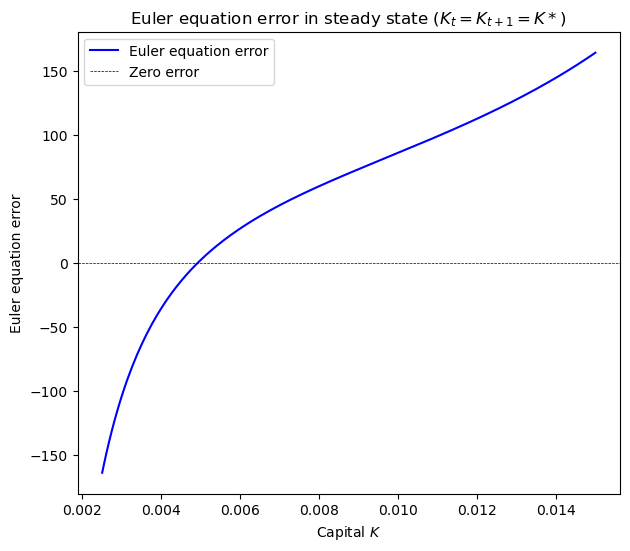

In [5]:
par = Parameters()

K_grid = np.linspace(0.0025, 0.015, 200)
errors = np.array([euler_err(K, K, par) for K in K_grid])

plt.figure(figsize=(7, 6))
plt.plot(K_grid, errors, color='blue', label='Euler equation error')
plt.axhline(0, color='black', lw=0.5, ls='--', label ='Zero error')
plt.xlabel('Capital $K$')
plt.ylabel('Euler equation error')
plt.title('Euler equation error in steady state ($K_t = K_{t+1} = K*$)')
plt.legend()
plt.show()

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

The use of `compute_prices` instead of repeating calculations is good practice. 

Even though it is not strictly required, it could have been nice to calculate a Capital-Labor ratio to see how it changes in the different steady-state cases.

Only extracting the interest rate r inside `euler_err` is clean, no need to assign variables that won't be used. 

Overall, the code in this part is well-structured and easy to read, executes without errors and displays correct solutions.

***
## ***Part 2 - Steady State***
***

#### 1. Define a class `SteadyState` that stores all steady-state quantities and prices.

In [6]:
@dataclass
class SteadyState:
    """Stores all steady-state values for the OLG model."""

    # Parameter object used to compute the steady state
    par: Parameters = None 

    # Macroeconomic aggregates
    K: float = None
    L: float = None
    Y: float = None

    # Factor prices
    r: float = None
    w: float = None

    # Capitalist variables (allocations and consumption)
    a: float = None
    b: float = None
    c_y_k: float = None
    c_o_k: float = None

    # Worker variables (consumption)
    c_y_w: float = None
    c_o_w: float = None

    # Government pension
    p: float = None

#### 2. Implement a function `compute_steady_state()`

Uses `euler_err` with $K_{t+1} = K_t = K^*$ and verifies the goods market clearing condition. Written generally so it works for any $\tau_a \geq 0$.


In [7]:
def compute_steady_state(par: Parameters, euler_fn = euler_err):
    """
    Compute the steady-state equilibrium for the OLG model.
    Works for both tau_a = 0 (baseline) and tau_a > 0 (wealth tax).

    Parameters
    ----------
    par : Parameters
        Model parameters
    euler_fn : callable, optional
        Euler equation error function (default: euler_err)

    Returns
    -------
    eq : SteadyState
        Steady-state equilibrium with all quantities and prices
    """
    # Find steady-state capital where euler_err(K, K, par) = 0
    res = root_scalar(lambda K: euler_fn(K, K, par), bracket=(0.0025, 0.015))
    K = res.root

    L = 0.5 * par.N_w

    # Factor prices
    r, w = compute_prices(K, par)
    Y = par.z * K ** par.alpha * L ** (1 - par.alpha)

    # Capitalist allocations and consumption
    a = 2 * K / par.N_k
    T_a = 0.5 * par.N_k * par.tau_a * (1 + r) * a
    b = par.phi * (1 - par.tau_a) * (1 + r) * a
    c_y_k = b + T_a - a
    c_o_k = (1 - par.phi) * (1 - par.tau_a) * (1 + r) * a + T_a

    # Worker consumption and government pension
    p = par.tau * w
    c_y_w = (1 - par.tau) * w + T_a
    c_o_w = p + T_a

    # Goods market clearing (verification)
    demand = 0.5 * par.N_w * (c_y_w + c_o_w) + 0.5 * par.N_k * (c_y_k + c_o_k + a)
    supply = Y + (1 - par.delta) * K
    assert abs(demand - supply) < 1e-6, f'Goods market does not clear: {demand:.10f} != {supply:.10f}'

    return SteadyState(
        par=par, K=K, L=L, Y=Y, r=r, w=w,
        a=a, b=b, c_y_k=c_y_k, c_o_k=c_o_k,
        c_y_w=c_y_w, c_o_w=c_o_w, p=p
    )

#### 3. Compute and report the steady-state equilibrium

In [8]:
def print_steady_state(eq: SteadyState):
    """
    Print equilibrium prices, allocations, and market clearing.

    Parameters
    ----------
    eq : SteadyState
        SteadyState of the OLG model
    """
    par = eq.par
    print("Steady-state equilibrium:")
    print("------------------------------------------------")
    print("  Workers:")
    print(f"    Consumption when young (c_y_w)  = {eq.c_y_w:.5f}")
    print(f"    Consumption when old (c_o_w)    = {eq.c_o_w:.5f}")
    print(f"    Pension (p)                     = {eq.p:.5f}")
    print("------------------------------------------------")
    print("  Capitalists:")
    print(f"    Consumption when young (c_y_k)  = {eq.c_y_k:.5f}")
    print(f"    Consumption when old (c_o_k)    = {eq.c_o_k:.5f}")
    print(f"    Savings (a)                     = {eq.a:.5f}")
    print(f"    Bequests (b)                    = {eq.b:.5f}")
    T_a = eq.par.tau_a * (1 + eq.r) * eq.K
    print(f"    Savings rate (s)                = {eq.a / (eq.b + T_a):.5f}")
    print("------------------------------------------------")
    print("  Firms:")
    print(f"    Capital (K)                     = {eq.K:.5f}")
    print(f"    Labor (L)                       = {eq.L:.5f}")
    print(f"    Output (Y)                      = {eq.Y:.5f}")
    print("------------------------------------------------")
    print("  Prices:")
    print(f"    Interest rate (r)               = {eq.r:.5f}")
    print(f"    Wage rate (w)                   = {eq.w:.5f}")
    print("------------------------------------------------")
    print("  Market Clearing:")
    demand = 0.5 * par.N_w * (eq.c_y_w + eq.c_o_w) + 0.5 * par.N_k * (eq.c_y_k + eq.c_o_k + eq.a)
    supply = eq.Y + (1 - par.delta) * eq.K
    print(f"    Goods market                    = {abs(demand - supply):.2e}")
    print("------------------------------------------------")

In [9]:
eq = compute_steady_state(par)

print_steady_state(eq)

Steady-state equilibrium:
------------------------------------------------
  Workers:
    Consumption when young (c_y_w)  = 0.09198
    Consumption when old (c_o_w)    = 0.03942
    Pension (p)                     = 0.03942
------------------------------------------------
  Capitalists:
    Consumption when young (c_y_k)  = 0.10246
    Consumption when old (c_o_k)    = 0.15168
    Savings (a)                     = 0.04922
    Bequests (b)                    = 0.15168
    Savings rate (s)                = 0.32452
------------------------------------------------
  Firms:
    Capital (K)                     = 0.00492
    Labor (L)                       = 0.40000
    Output (Y)                      = 0.08213
------------------------------------------------
  Prices:
    Interest rate (r)               = 5.16294
    Wage rate (w)                   = 0.13141
------------------------------------------------
  Market Clearing:
    Goods market                    = 0.00e+00
--------------------

#### 4. Compute the implied annualized interest rate (net of depreciation) to check whether the results from the 30-year model-period interest rate makes sense

In [10]:
r_annual = ((1 + eq.r) ** (1/30)) - 1
print(f'Annualized net interest rate: {r_annual:.2%}')

Annualized net interest rate: 6.25%


Given the interest level, we conclude that the interest rate make sense.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

Steady-state values are reported in a nice table, but it would have been nice if values that by definition are percentages to be reported as such (interest rate and savings rate). 

Annualized interest rate could also be added as part of the dataclass and computed inside the function, avoiding the extra cell. 

When running a root-finder function, it is nice to include an if-block checking if the function converged successfully, raising a `ValueError` if not. 

The print-function produces a nicely formatted table, but the code could be cleaner by completing all necessary calculations elsewhere, moving wealth tax transfer and the goods market clearing check inside `compute_steady_state`.

Overall the code in this part is very well-structured and easy to read/follow. Some minor changes are suggested, but these are mainly cosmetic. 

***
## ***Part 3 - Transition Dynamics***
***

#### 1. Create a `Simulation` class to store the simulated time series of all model variables

In [11]:
@dataclass
class Simulation:
    """Stores simulated time series arrays for each variable across the simulated periods."""

    K: np.ndarray = None
    L: np.ndarray = None
    Y: np.ndarray = None

    # Prices of factors
    r: np.ndarray = None
    w: np.ndarray = None

    # Capitalist variables
    a: np.ndarray = None
    b: np.ndarray = None
    c_y_k: np.ndarray = None
    c_o_k: np.ndarray = None

    # Worker variables
    c_y_w: np.ndarray = None
    c_o_w: np.ndarray = None

    p: np.ndarray = None

#### 2. Implement a function `simulate_olg()`

In [12]:
def initialize_sim(T):
    """
    Creates an object with empty arrays for the simulation of T periods.

    Parameters
    ----------
    T : int
        The number of periods that is to be simulated

    Returns
    -------
    sim : Simulation
        Simulation object with empty arrays
    """
    sim = Simulation()

    sim.K = np.empty(T)
    sim.L = np.empty(T)
    sim.Y = np.empty(T)
    
    sim.r = np.empty(T)
    sim.w = np.empty(T)
    
    sim.a = np.empty(T)
    sim.b = np.empty(T)
    sim.c_y_k = np.empty(T)
    sim.c_o_k = np.empty(T)
    
    sim.c_y_w = np.empty(T)
    sim.c_o_w = np.empty(T)
    
    sim.p = np.empty(T)

    return sim

In [13]:
def simulate_olg(K0, T, par: Parameters, euler_fn = euler_err):
    """
    Simulates transitional dynamics of the overlapping generations model starting from an initial capital stock K0.

    Parameters
    ----------
    K0 : float
        Total initial capital stock
    T : int
        The number of periods that is to be simulated
    par : Parameters
        Model parameters
    euler_fn : callable, optional
        Euler equation error function, where default is euler_err.

    Returns
    -------
    sim : Simulation
        Simulation object containing time series for all model variables
    """
    sim = initialize_sim(T)
    sim.K[0] = K0
    sim.L[:] = 0.5 * par.N_w

    for t in range(T):
        K = sim.K[t]
        L = sim.L[t]

        # Prices and output
        sim.r[t], sim.w[t] = compute_prices(K, par)
        sim.Y[t] = par.z * K ** par.alpha * L ** (1 - par.alpha)

        # Savings previous period
        a_prev = 2 * K / par.N_k

        # Wealth tax transfer equation
        T_a = 0.5 * par.N_k * par.tau_a * (1 + sim.r[t]) * a_prev

        # Young capitalists receive bequest:
        sim.b[t] = par.phi * (1 - par.tau_a) * (1 + sim.r[t]) * a_prev

        # Capital of next period
        if t < T - 1:
            K_max = (sim.b[t] + T_a) * par.N_k / 2 * 0.999 # upper bound for root-finding
            res = root_scalar(
                lambda K_next: euler_fn(K_next, K, par),
                bracket=(1e-6, K_max),
            )
            if not res.converged:
                print(f'Root-finding failed at t={t}')
            sim.K[t + 1] = res.root

        # Savings of current period
        if t < T - 1:
            sim.a[t] = 2 * sim.K[t + 1] / par.N_k
        else:
            sim.a[t] = a_prev  # last period approximation

        # Consumption of capitalists
        sim.c_y_k[t] = sim.b[t] + T_a - sim.a[t]
        sim.c_o_k[t] = (1 - par.phi) * (1 - par.tau_a) * (1 + sim.r[t]) * a_prev + T_a

        # Consumption of workers
        sim.p[t] = par.tau * sim.w[t]
        sim.c_y_w[t] = (1 - par.tau) * sim.w[t] + T_a
        sim.c_o_w[t] = sim.p[t] + T_a

        # Goods market clearing check
        demand = 0.5 * par.N_w * (sim.c_y_w[t] + sim.c_o_w[t]) + 0.5 * par.N_k * (sim.c_y_k[t] + sim.c_o_k[t] + sim.a[t])
        supply = sim.Y[t] + (1 - par.delta) * sim.K[t]
        assert abs(demand - supply) < 1e-6, f'Goods market does not clear in period {t}'

    return sim

#### 3. Verify the steady state by simulating from $K_0 = K^*/2$

In [14]:
T = 20

K0 = eq.K / 2 # Half the steady-state capital stock is the starting point

# simulates the transition dynamics
sim = simulate_olg(K0, T, par)

# Convergence to steady state check 
print(f'{"Period":>8s}     {"K":<12s} {"% dev from K*=" + f"{eq.K:.6f}":>20s}')
print("-" * 37)
for t in [0, 5, 10, 15, 19]:
    dev = (sim.K[t] / eq.K - 1)
    print(f'{t:>8d} {sim.K[t]:12.6f} {dev:+14.2%}')
print("-" * 37)
print(f'{"K*":>8s} {eq.K:12.6f}')

  Period     K            % dev from K*=0.004922
-------------------------------------
       0     0.002461        -50.00%
       5     0.004834         -1.79%
      10     0.004920         -0.05%
      15     0.004922         -0.00%
      19     0.004922         -0.00%
-------------------------------------
      K*     0.004922


#### 4. Create a figure with 5×2 subplots showing the simulated series

In [15]:
def plot_simulation(eq, sim, par, eq_new=None):
    """
    Plots the simulated transition path of variables.

    Parameters
    ----------
    eq : SteadyState
        Baseline steady state.
    sim : Simulation
        The simulated transition path.
    par : Parameters
        Model parameters for the baseline steady state.
    eq_new : SteadyState, optional
        The new  equilibrium steady state after tax policy change.
    """
    
    # calculates the savings rate time series for both the simulation and the initial steady state
    T_a_sim = par.tau_a * (1 + sim.r) * sim.K
    T_a_eq = eq.par.tau_a * (1 + eq.r) * eq.K
    sim_s = sim.a / (sim.b + T_a_sim)
    eq_s = eq.a / (eq.b + T_a_eq)

    # creates a list of tuples for the variables to be plotted, where boolean indicated whether to plot percentage deviations from the initial steady state
    plots = [
        (sim.Y, eq.Y, 'Output $Y_t$', True),
        (sim.K, eq.K, 'Capital $K_t$', True),
        (sim.w, eq.w, 'Wage $w_t$', True),
        (sim.r, eq.r, 'Interest rate $r_t$', False),
        (sim.b, eq.b, 'Bequests $b_t$', True),
        (sim_s, eq_s, 'Savings rate $s_t$', False),
        (sim.c_y_w, eq.c_y_w, 'Young worker $c_y^w$', True),
        (sim.c_o_w, eq.c_o_w, 'Old worker $c_o^w$', True),
        (sim.c_y_k, eq.c_y_k, 'Young capitalist $c_y^k$', True),
        (sim.c_o_k, eq.c_o_k, 'Old capitalist $c_o^k$', True),
    ]

    # If a new steady state is provided, calculate the new savings rate and create a list of the new steady state values in the same order as the plots list
    if eq_new is not None:
        T_a_new = eq_new.par.tau_a * (1 + eq_new.r) * eq_new.K
        eq_new_s = eq_new.a / (eq_new.b + T_a_new)
        new_ss = [eq_new.Y, eq_new.K, eq_new.w, eq_new.r, eq_new.b, eq_new_s,
                  eq_new.c_y_w, eq_new.c_o_w, eq_new.c_y_k, eq_new.c_o_k]

    # creates subplots to plot the transition paths of the variables, with appropriate titles, labels, and legends
    fig, axes = plt.subplots(5, 2, figsize=(10, 14), constrained_layout=True)

    # Loops through the list of plots and creates a plot for each variable
    for i, (series, ss_val, title, pct_dev) in enumerate(plots):
        ax = axes[i // 2, i % 2]

        # Plots the variables that are shown as percentage deviations from the initial steady state
        if pct_dev:
            ax.plot((series - ss_val) / ss_val,
                    marker='o', markersize=4, color='blue', label = 'Simulation')
            ax.axhline(0, color='black', lw=0.5, ls='--', label='Initial SS')
            if eq_new is not None:
                ax.axhline((new_ss[i] - ss_val) / ss_val,
                           color='red', lw=0.5, ls='--', label='New SS')
            ax.set_ylabel('% deviation from initial SS')
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))

        # plots the variables that are shown in levels
        else:
            ax.plot(series, marker='o', markersize=4, color='blue')
            ax.axhline(ss_val, color='black', lw=0.5, ls='--',)
            if eq_new is not None:
                ax.axhline(new_ss[i], color='red', lw=0.5, ls='--')
            ax.set_ylabel('in percentage %')
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))

        ax.set_title(title)
        ax.set_xlabel('Period')
        # adds a legend to the first subplot
        if i == 0:
            ax.legend()
    plt.show()

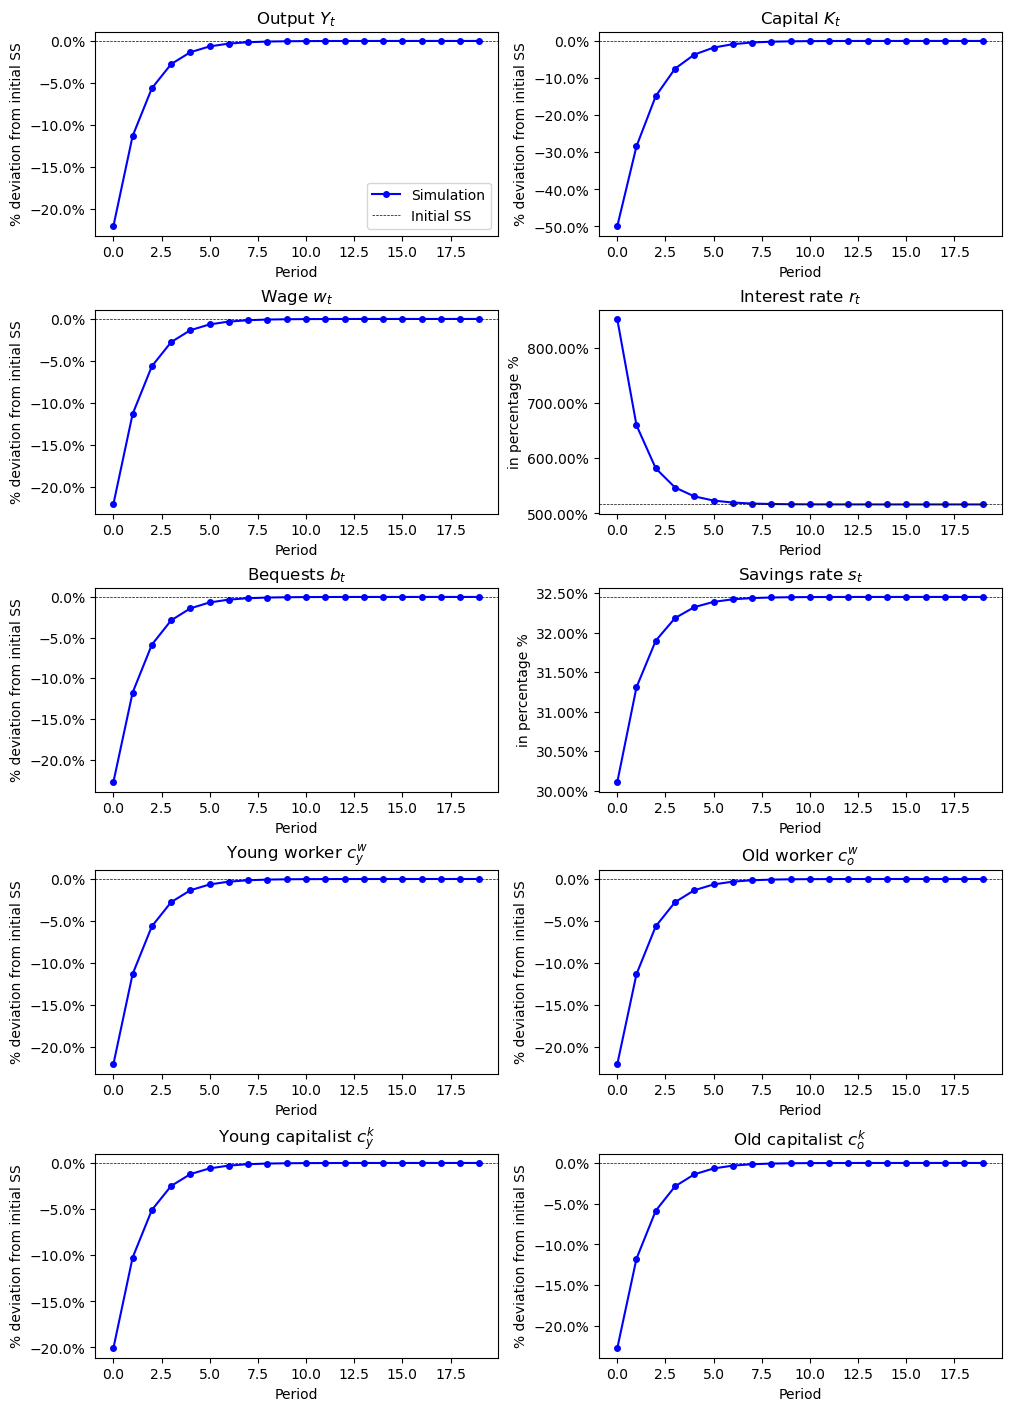

In [16]:
plot_simulation(eq, sim, par)

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

The separate `initialize_sim` function is a good way of keeping `simulate_olg` more clean and easy to read.

Using a dynamic bracket for the root finder is good practice, it ensures that values are economically meaningful where a fixed bracket could lead to problems in extreme cases. 

Checking if root-finder converged and if goods-market clears in each loop inside `simulate_olg` is good practice. 

Notice that `compute_steady_state` and `simulate_olg` both compute and return the same variables on a period basis (`simulate_olg` returns several periods). This means that you could make the code slightly more efficient by adding a `compute_period` function that computes all of these variables for a single period. 

The presentation of how capital converges to steady-state from half the stock clearly shows that the function is correctly implemented. Also nice that you only printed a few selected periods instead of all 20. 

Preparing the plot-function for cases with both old and new steady-states is nicely done.

Overall, code in this part is clean and efficient, and runs correctly. Some repeating calculations could be avoided by defining a `compute_period` function to pass inside `compute_steady_state` and `simulate_olg`. 

***
## ***Part 4 - Introduction of a Wealth Tax***
***

#### 1. Updating the `Parameters` class so it includes the wealth tax rate set to $\tau_a = 0.05$

In [17]:
par_tax = Parameters(tau_a=0.05)

#### 2. Modifying the functions so they include the wealth tax

In the following task we have redefined the functions `euler_err`, `compute_steady_state` and `simulate_olg` so that they now implement the wealth tax when $\tau_a > 0$. 

This is not the case for task 1-3, due to the fact that the parameter $\tau_a$ is set to 0 initially.

#### 3. Computing the new steady state with the wealth tax

In [18]:
# Compute steady states
eq_tax = compute_steady_state(par_tax)

# Report wealth tax steady state
print(f"Wealth tax (tau_a = {par_tax.tau_a:.2f}):")
print_steady_state(eq_tax)

Wealth tax (tau_a = 0.05):
Steady-state equilibrium:
------------------------------------------------
  Workers:
    Consumption when young (c_y_w)  = 0.09105
    Consumption when old (c_o_w)    = 0.03986
    Pension (p)                     = 0.03839
------------------------------------------------
  Capitalists:
    Consumption when young (c_y_k)  = 0.09591
    Consumption when old (c_o_k)    = 0.14163
    Savings (a)                     = 0.04572
    Bequests (b)                    = 0.14015
    Savings rate (s)                = 0.32283
------------------------------------------------
  Firms:
    Capital (K)                     = 0.00457
    Labor (L)                       = 0.40000
    Output (Y)                      = 0.07998
------------------------------------------------
  Prices:
    Interest rate (r)               = 5.45335
    Wage rate (w)                   = 0.12796
------------------------------------------------
  Market Clearing:
    Goods market                    = 1.

In [19]:
# Wealth tax transfers for each steady state
T_a_eq = eq.par.tau_a * (1 + eq.r) * eq.K
T_a_tax = eq_tax.par.tau_a * (1 + eq_tax.r) * eq_tax.K

# Savings rates: s = a / (b + T_a)
s_base = eq.a / (eq.b + T_a_eq)
s_tax = eq_tax.a / (eq_tax.b + T_a_tax)

# Compare capital and savings rate across steady states
print(f'{"":30s} {"Baseline":>12s} {"Wealth tax":>12s} {"Change":>10s}')
print("-" * 67)
print(f'{"Capital (K)":30s} {eq.K:12.6f} {eq_tax.K:12.6f} {(eq_tax.K/eq.K - 1):+10.2%}')
print(f'{"Savings rate (s)":30s} {s_base:12.6f} {s_tax:12.6f} {(s_tax/s_base - 1):+10.2%}')

                                   Baseline   Wealth tax     Change
-------------------------------------------------------------------
Capital (K)                        0.004922     0.004572     -7.11%
Savings rate (s)                   0.324520     0.322830     -0.52%


Both capital and the savings rate decline with the wealth tax. Capital falls by 7.11% because the tax reduces the after-tax return on capitalist assets, lowering the incentive to save. The savings rate also falls slightly (–0.52%) as the tax erodes after-tax wealth while the lump-sum transfer partially offsets the loss in income, reducing the fraction of available resources that capitalists choose to save. The lower capital stock leads to reduced output and wages, but a higher interest rate as capital becomes scarcer.

#### 4. Simulating the transition path for T = 20 periods when the economy starts in the steady state without a wealth tax

In [20]:
# Number of periods
T = 20

# Capital stock in steady state without tax
K0 = eq.K

# Simulate transition after wealth tax is introduced as a surprise in t=0
sim_tax = simulate_olg(K0, T, par=par_tax)


#### 5. Plotting the transition paths for the same variables as in part 3

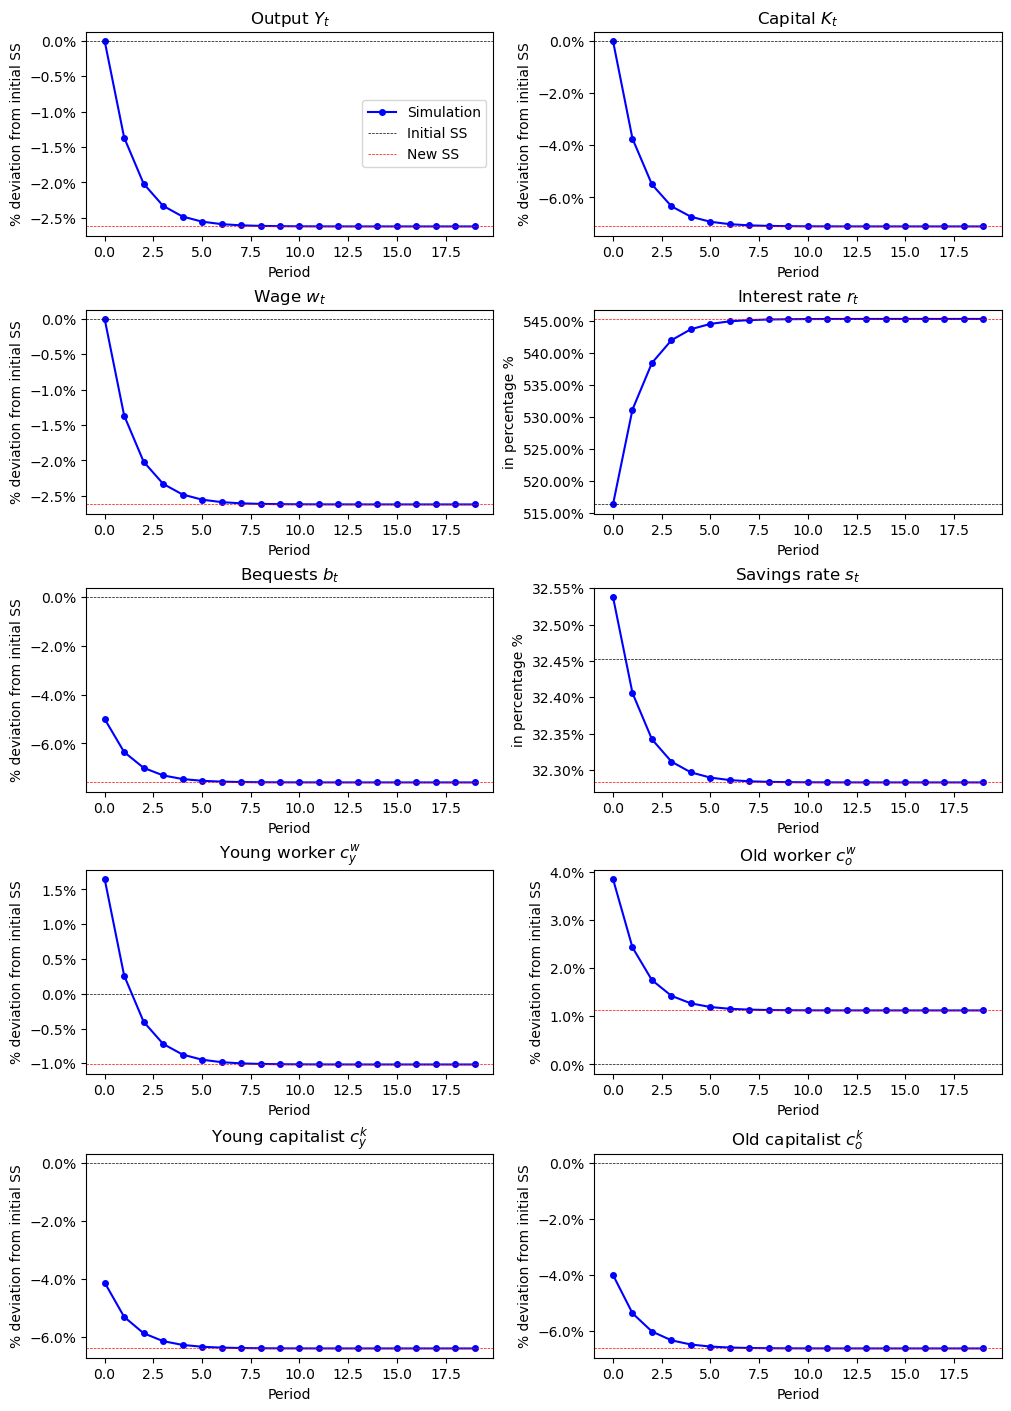

In [21]:
plot_simulation(eq, sim_tax, par_tax, eq_new=eq_tax)

#### 6. Discussion: Who is better or worse off?


##### <u>Capitalists:</u>
They are unambiguously worse off, both along the transition and in the new steady state. The wealth tax reduces after-tax capital returns, which lowers bequests and consumption for both young and old capitalists. In the new steady state, young capitalist consumption falls by about 6.4% and old capitalist consumption by about 6.6% relative to the baseline.

##### <u>Workers:</u>
Workers have a mixed experience. Old workers benefit from the lump-sum transfer, which more than offsets the decline in pensions from lower wages. Therefore their consumption rises by about 1.1% in the new steady state. Young workers, however, are slightly worse off (–1.0%) because the fall in wages caused by reduced capital outweighs the transfer they receive.

Overall, the wealth tax redistributes from capitalists to workers, but the decline in capital (–7.1%) and output (–2.6%) depresses wages enough to partially erode workers' gains in the long run.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

Functions in previous parts are correctly prepared for the introduction of a wealth-tax, which makes this part very clean by only requiring a new parameter instance where wealth tax is changed. 

The wealth-tax header over steady-state results could have been added inside the print-function using an if-statement, but that is a very minor change. 

Savings rate could be implemented in the general functions, then printing it with the rest of the steady-state values instead of adding another code cell.

Plots are nicely formatted again, and clearly show how the economy moves towards a new steady-state when wealth-tax is introduced.

Overall, the code in this part is well written and easy to follow, but some changes in earlier functions could have made it even more efficient.

***
## ***Part 5 - Social Welfare and The Optimal Wealth Tax***
***

#### 1. Computing the social welfare for the steady states with and without the wealth tax

In [22]:
def u(c, par):
    """
    CRRA utility function.

    Parameters
    ----------
    c : float
        Consumption level
    par : Parameters
        Model parameters

    Returns
    -------
    float
        Utility evaluated at c
    """
    if par.gamma == 1:
        return np.log(c)
    return (c ** (1 - par.gamma)) / (1 - par.gamma)

In [23]:
def social_welfare(eq, par):
    """
    Compute utilitarian social welfare at a given steady state.

    Parameters
    ----------
    eq : SteadyState
        Steady-state equilibrium
    par : Parameters
        Model parameters

    Returns
    -------
    SW : float
        Aggregate social welfare
    U_y_w : float
        Lifetime utility of a young worker
    U_o_w : float
        Utility of an old worker
    U_y_k : float
        Lifetime utility of a young capitalist
    U_o_k : float
        Utility of an old capitalist
    """
    # Young worker: u(c_y^w) + beta * u(c_o^w)
    U_y_w = u(eq.c_y_w, par) + par.beta * u(eq.c_o_w, par)
    # Old worker (dies at end of period)
    U_o_w = u(eq.c_o_w, par)
    # Young capitalist: u(c_y^k) + beta * u(c_o^k)
    U_y_k = u(eq.c_y_k, par) + par.beta * u(eq.c_o_k, par)
    # Old capitalist
    U_o_k = u(eq.c_o_k, par)
    
    SW = 0.5 * par.N_w * (U_y_w + U_o_w) + 0.5 * par.N_k * (U_y_k + U_o_k)
    return SW, U_y_w, U_o_w, U_y_k, U_o_k

In [24]:
# Computing the social welfare for both steady states
SW_base, Uyw_b, Uow_b, Uyk_b, Uok_b = social_welfare(eq, par)
SW_tax,  Uyw_t, Uow_t, Uyk_t, Uok_t = social_welfare(eq_tax, par_tax)

# Comparing welfare across steady states
print(f'{"":30s} {"No tax":>12s} {"Wealth tax":>12s} {"Change":>10s}')
print("-" * 67)
print(f'{"Social welfare (SW)":30s} {SW_base:12.4f} {SW_tax:12.4f} {SW_tax - SW_base:+10.4f}')
print()
print(f'{"Young workers (U_y_w)":30s} {Uyw_b:12.4f} {Uyw_t:12.4f} {Uyw_t - Uyw_b:+10.4f}')
print(f'{"Old workers (U_o_w)":30s} {Uow_b:12.4f} {Uow_t:12.4f} {Uow_t - Uow_b:+10.4f}')
print(f'{"Young capitalists (U_y_k)":30s} {Uyk_b:12.4f} {Uyk_t:12.4f} {Uyk_t - Uyk_b:+10.4f}')
print(f'{"Old capitalists (U_o_k)":30s} {Uok_b:12.4f} {Uok_t:12.4f} {Uok_t - Uok_b:+10.4f}')
print("-" * 67)


                                     No tax   Wealth tax     Change
-------------------------------------------------------------------
Social welfare (SW)                -29.5652     -29.5342    +0.0310

Young workers (U_y_w)              -36.1159     -35.9704    +0.1455
Old workers (U_o_w)                -31.8636     -31.4751    +0.3885
Young capitalists (U_y_k)          -16.4970     -17.7561    -1.2591
Old capitalists (U_o_k)             -7.2375      -7.8044    -0.5669
-------------------------------------------------------------------


The steady state with the wealth tax yields higher social welfare (SW = –29.5342 vs. –29.5652). On average, households prefer the economy with the wealth tax.

Workers drive this result. Both young and old workers gain (+0.15 and +0.39), as the lump-sum transfer from the wealth tax more than compensates for slightly lower wages. Since workers make up 80% of the population, their gains dominate in the welfare function. Capitalists are worse off (–1.26 and –0.57) due to reduced after-tax returns, but their 20% population share means their losses are outweighed.

#### 2. Finding the socially optimal wealth tax rate

In [25]:
def neg_social_welfare(tau_a):
    """
    Negative social welfare as a function of the wealth tax rate.
    Used with a minimizer to find the welfare-maximizing tax rate.

    Parameters
    ----------
    tau_a : float
        Wealth tax rate

    Returns
    -------
    float
        Negative social welfare (minimizing this maximizes welfare)
    """
    par_temp = Parameters(tau_a=tau_a)
    eq_temp = compute_steady_state(par_temp)
    SW, *_ = social_welfare(eq_temp, par_temp)
    return -SW


In [26]:
# Find the welfare-maximizing wealth tax rate
res = minimize_scalar(neg_social_welfare, bounds=(0, 0.25), method='bounded')
tau_a_star = res.x
print("-" * 42)
print(f'Optimal wealth tax rate: tau_a* = {tau_a_star:.5f}')
print("-" * 42)

------------------------------------------
Optimal wealth tax rate: tau_a* = 0.04056
------------------------------------------


#### 3. Solving for the steady state using $\tau_a^*$

In [27]:
par_opt = Parameters(tau_a=tau_a_star)
eq_opt = compute_steady_state(par_opt)

# Percentage changes vs. baseline (no wealth tax)
dY = (eq_opt.Y - eq.Y) / eq.Y
dK = (eq_opt.K - eq.K) / eq.K

print(f'{"":30s} {"Original SS":>12s} {"Optimal tax":>12s} {"Change":>10s}')
print("-" * 67)
print(f'{"Output (Y)":30s} {eq.Y:12.4f} {eq_opt.Y:12.4f} {dY:+10.2%}')
print(f'{"Capital (K)":30s} {eq.K:12.4f} {eq_opt.K:12.4f} {dK:+10.2%}')
print("-" * 67)

                                Original SS  Optimal tax     Change
-------------------------------------------------------------------
Output (Y)                           0.0821       0.0804     -2.12%
Capital (K)                          0.0049       0.0046     -5.78%
-------------------------------------------------------------------


Despite lower output (–2.12%) and capital (–5.78%), the optimal wealth tax ($\tau_a* ≈ 0.0406$) maximizes social welfare because it redistributes resources from capitalists to workers. Workers make up 80% of the population and receive lump-sum transfers that increase their consumption, particularly for old workers. The welfare gains from this redistribution outweigh the efficiency losses from reduced capital accumulation. In other words, the economy produces less in aggregate, but the distribution of consumption becomes more equal, which increases average utility under the concave CRRA utility function.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

Separate utility function to handle different gamma-cases is good practice, Nice! 

Inside `social_welfare`, if  you calculate old utility first, you can call that variable in young utility rather than calling the function again. This makes the code more clean and efficient by reducing number of calculations. 

It is very good that you report the utilities and social welfare with and without wealth-tax, as well as the change, next to each other, but the effect could be made even more clear with change in percentage-terms.

Reporting optimal social welfare as well as the optimal wealth-tax rate would have been nice.

Overall a good solution in this part, some minor changes suggested. 

***
## ***Part 6 - Uncertainty About Wealth Tax***
***

#### 1. Updating the parameters class to include the new attributes introduced in this part

In [28]:
par_unc = Parameters(tau_a=0.0, pi_a=0.5, tau_a_iid = 0.05)

#### 2. Implementing a function euler_err_uncertain() which evaluetes the euler equation error

In [29]:
def euler_err_uncertain(K_next, K, par: Parameters):
    """
    Euler equation error with uncertainty about next period's wealth tax.

    Parameters
    ----------
    K_next : float
        Aggregate capital stock next period
    K : float
        Aggregate capital stock today
    par : Parameters
        Model parameters (includes pi_a and tau_a_iid)

    Returns
    -------
    float
        Euler equation error (LHS - RHS)
    """

    # Factor prices
    r, _ = compute_prices(K, par)
    r_next, _ = compute_prices(K_next, par)

    # Individual savings from asset market clearing
    a = 2 * K_next / par.N_k
    a_prev = 2 * K / par.N_k

    # Today's known values (using current actual tau_a)
    T_a = 0.5 * par.N_k * par.tau_a * (1 + r) * a_prev
    b = par.phi * (1 - par.tau_a) * (1 + r) * a_prev

    # LHS: known today
    c_y = b + T_a - a
    lhs = c_y ** (-par.gamma)

    # RHS: expectation over two scenarios for tau_{a,t+1}

    # Scenario 1: no wealth tax next period (prob 1 - pi_a)
    c_o_0 = (1 - par.phi) * (1 + r_next) * a        # Old capitalist consumption without tax
    term_0 = 1.0 * c_o_0 ** (-par.gamma)            # Marginal utility weighted by full after-tax share

    # Scenario 2: wealth tax enacted next period (prob pi_a)
    T_a_next_iid = 0.5 * par.N_k * par.tau_a_iid * (1 + r_next) * a  # Transfer if tax is enacted
    c_o_iid = (1 - par.phi) * (1 - par.tau_a_iid) * (1 + r_next) * a + T_a_next_iid  # Consumption with tax and transfer
    term_iid = (1 - par.tau_a_iid) * c_o_iid ** (-par.gamma)  # Marginal utility scaled by after-tax share

    # Probability-weighted expected value across both scenarios
    E_term = (1 - par.pi_a) * term_0 + par.pi_a * term_iid
    rhs = par.beta * (1 + r_next) * (1 - par.phi) * E_term

    return lhs - rhs

#### 3. Solving for the new steady state when there is uncertainty about the wealth tax policy next period

In [30]:
# Steady state with uncertainty but actual tau_a = 0 forever
eq_unc = compute_steady_state(par_unc, euler_fn=euler_err_uncertain)

# Compare with Part 2 steady state (no uncertainty)
par_base = Parameters(tau_a=0.0, pi_a=0.0)
eq_base = compute_steady_state(par_base)

# Savings rates for both scenarios
T_a_base = eq_base.par.tau_a * (1 + eq_base.r) * eq_base.K
T_a_unc = eq_unc.par.tau_a * (1 + eq_unc.r) * eq_unc.K
s1 = eq_base.a / (eq_base.b + T_a_base)
s2 = eq_unc.a / (eq_unc.b + T_a_unc)
# Compare steady states
print(f'{"Comparison: Part 2 vs Part 6":^66s}')
print(f'{"":30s} {"No uncert.":>12s} {"Uncertainty":>12s} {"Change":>10s}')
print("-" * 67)
print("  Workers:")
print(f'{"    Consumption young (c_y_w)":30s} {eq_base.c_y_w:12.4f} {eq_unc.c_y_w:12.4f} {(eq_unc.c_y_w/eq_base.c_y_w - 1):+9.2%}')
print(f'{"    Consumption old (c_o_w)":30s} {eq_base.c_o_w:12.4f} {eq_unc.c_o_w:12.4f} {(eq_unc.c_o_w/eq_base.c_o_w - 1):+9.2%}')
print(f'{"    Pension (p)":30s} {eq_base.p:12.4f} {eq_unc.p:12.4f} {(eq_unc.p/eq_base.p - 1):+9.2%}')
print("-" * 67)
print("  Capitalists:")
print(f'{"    Consumption young (c_y_k)":30s} {eq_base.c_y_k:12.4f} {eq_unc.c_y_k:12.4f} {(eq_unc.c_y_k/eq_base.c_y_k - 1):+9.2%}')
print(f'{"    Consumption old (c_o_k)":30s} {eq_base.c_o_k:12.4f} {eq_unc.c_o_k:12.4f} {(eq_unc.c_o_k/eq_base.c_o_k - 1):+9.2%}')
print(f'{"    Savings (a)":30s} {eq_base.a:12.4f} {eq_unc.a:12.4f} {(eq_unc.a/eq_base.a - 1):+9.2%}')
print(f'{"    Bequests (b)":30s} {eq_base.b:12.4f} {eq_unc.b:12.4f} {(eq_unc.b/eq_base.b - 1):+9.2%}')
print(f'{"    Savings rate (s)":30s} {s1:12.4f} {s2:12.4f} {(s2/s1 - 1):+9.2%}')
print("-" * 67)
print("  Firms:")
print(f'{"    Capital (K)":30s} {eq_base.K:12.4f} {eq_unc.K:12.4f} {(eq_unc.K/eq_base.K - 1):+9.2%}')
print(f'{"    Labor (L)":30s} {eq_base.L:12.4f} {eq_unc.L:12.4f} {(eq_unc.L/eq_base.L - 1):+9.2%}')
print(f'{"    Output (Y)":30s} {eq_base.Y:12.4f} {eq_unc.Y:12.4f} {(eq_unc.Y/eq_base.Y - 1):+9.2%}')
print("-" * 67)
print("  Prices:")
print(f'{"    Interest rate (r)":30s} {eq_base.r:12.4f} {eq_unc.r:12.4f} {(eq_unc.r/eq_base.r - 1):+9.2%}')
print(f'{"    Wage rate (w)":30s} {eq_base.w:12.4f} {eq_unc.w:12.4f} {(eq_unc.w/eq_base.w - 1):+9.2%}')
print("-" * 67)

                   Comparison: Part 2 vs Part 6                   
                                 No uncert.  Uncertainty     Change
-------------------------------------------------------------------
  Workers:
    Consumption young (c_y_w)        0.0920       0.0924    +0.50%
    Consumption old (c_o_w)          0.0394       0.0396    +0.50%
    Pension (p)                      0.0394       0.0396    +0.50%
-------------------------------------------------------------------
  Capitalists:
    Consumption young (c_y_k)        0.1025       0.1026    +0.10%
    Consumption old (c_o_k)          0.1517       0.1525    +0.52%
    Savings (a)                      0.0492       0.0499    +1.39%
    Bequests (b)                     0.1517       0.1525    +0.52%
    Savings rate (s)                 0.3245       0.3273    +0.87%
-------------------------------------------------------------------
  Firms:
    Capital (K)                      0.0049       0.0050    +1.39%
    Labor (L)          

No, the steady state is not identical to the one in Part 2. Although the actual wealth tax rate remains $\tau_a = 0$, the possibility of a future tax changes capitalist behavior. With a risk aversion of $\gamma = 2.1$, capitalists respond to the uncertainty by saving more as a buffer against the risk of reduced after-tax returns. This results in a higher capital stock, which in turn raises output and wages while lowering the interest rate.

#### 4. Adapting the `simulate_olg()` function so that we can compute the transition paths with uncertainty about the wealth tax policy

In [31]:
# Number of periods
T = 20

# Capital stock in steady state without uncertainty 
K_star = eq_base.K

# Simulating the transition path under uncertainty starting from the old steady state
sim_unc = simulate_olg(K_star, T, par=par_unc, euler_fn=euler_err_uncertain)

#### 5. How does the new steady state compare to the ones you found in parts 2 and 5? Briefly explain the key differences and the underlying mechanisms

In [32]:
# Savings rate at optimal tax  rate and with uncertainty
T_a_opt = eq_opt.par.tau_a * (1 + eq_opt.r) * eq_opt.K
T_a_base = eq_base.par.tau_a * (1 + eq_base.r) * eq_base.K
T_a_unc = eq_unc.par.tau_a * (1 + eq_unc.r) * eq_unc.K
s_opt = eq_opt.a / (eq_opt.b + T_a_opt)
s_base = eq_base.a / (eq_base.b + T_a_base)
s_unc = eq_unc.a / (eq_unc.b + T_a_unc)

# Printing out the results for Part 2, Part 5, and Part 6 steady states
print(f'{"Steady State":30s} {"No tax":>12s} {"Opt. tax":>12s} {"Uncert.":>12s}')
print(f'{"":30s} {"(Part 2)":>12s} {"(Part 5)":>12s} {"(Part 6)":>12s}')
print("-" * 69)
print(f'{"Capital (K)":30s} {eq_base.K:12.4f} {eq_opt.K:12.4f} {eq_unc.K:12.4f}')
print(f'{"Output (Y)":30s} {eq_base.Y:12.4f} {eq_opt.Y:12.4f} {eq_unc.Y:12.4f}')
print(f'{"Interest rate (r)":30s} {eq_base.r:12.4f} {eq_opt.r:12.4f} {eq_unc.r:12.4f}')
print(f'{"Wage (w)":30s} {eq_base.w:12.4f} {eq_opt.w:12.4f} {eq_unc.w:12.4f}')
print(f'{"Savings rate (s)":30s} {s_base:12.4f} {s_opt:12.4f} {s_unc:12.4f}')
print()
print(f'{"Young capitalist (c_y_k)":30s} {eq_base.c_y_k:12.4f} {eq_opt.c_y_k:12.4f} {eq_unc.c_y_k:12.4f}')
print(f'{"Old capitalist (c_o_k)":30s} {eq_base.c_o_k:12.4f} {eq_opt.c_o_k:12.4f} {eq_unc.c_o_k:12.4f}')
print(f'{"Young worker (c_y_w)":30s} {eq_base.c_y_w:12.4f} {eq_opt.c_y_w:12.4f} {eq_unc.c_y_w:12.4f}')
print(f'{"Old worker (c_o_w)":30s} {eq_base.c_o_w:12.4f} {eq_opt.c_o_w:12.4f} {eq_unc.c_o_w:12.4f}')
print("-" * 69)

Steady State                         No tax     Opt. tax      Uncert.
                                   (Part 2)     (Part 5)     (Part 6)
---------------------------------------------------------------------
Capital (K)                          0.0049       0.0046       0.0050
Output (Y)                           0.0821       0.0804       0.0825
Interest rate (r)                    5.1629       5.3964       5.1101
Wage (w)                             0.1314       0.1286       0.1321
Savings rate (s)                     0.3245       0.3232       0.3273

Young capitalist (c_y_k)             0.1025       0.0971       0.1026
Old capitalist (c_o_k)               0.1517       0.1435       0.1525
Young worker (c_y_w)                 0.0920       0.0912       0.0924
Old worker (c_o_w)                   0.0394       0.0398       0.0396
---------------------------------------------------------------------


The three steady states differ in capital: Part 2 (K = 0.004922), Part 5 with optimal tax (K = 0.004638), and Part 6 with uncertainty (K = 0.004991).

In Part 5, the wealth tax directly reduces after-tax returns, discouraging saving. Capital and output fall, but redistribution from capitalists to workers improves aggregate welfare despite the smaller economy. Capitalist consumption drops significantly while workers benefit from transfers.

In Part 6, no tax is imposed, yet the mere possibility of a future tax alters behavior. Capitalists face a 50% probability of reduced after-tax returns next period and, with high risk aversion ($\gamma = 2.1$), respond by saving more as a buffer. This pushes capital above the Part 2 level, raising output and wages. Unlike Part 5, all household types benefit, including capitalists, since there is no actual redistribution, only increased saving.

The key insight is that the two mechanisms work in opposite directions: an actual tax reduces capital through lower returns (Part 5), while uncertainty increases capital through risk-driven saving (Part 6). This explains why Part 6 has the highest capital stock despite no tax being introduced.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

Nice implementation of the alternative euler-error function under uncertainty. It handles wealth-tax uncertainty without actual wealth-tax correctly.

Comparing steady-states next to each other with percentage changes is nice, but this could also have been implemented in the print-function from earlier, letting you use it to compare all steady-state cases without the extra code. In this part you are writing two extra cells with several lines to print output that could have been done in the overall function. 

Overall nicely done, calculations are all correctly implemented, but printing of output could have been added conditionally to the previous print-function. 